# Preprocessing

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

## Upload Dataset

In [17]:
data = pd.read_csv('../amazon_delivery.csv')
data.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Traffic_Code,Weather_Code,Vehicle_Code,Category_Code
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,NaN,0,0,2
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,NaN,4,1,4
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,NaN,5,0,14
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,NaN,0,0,3
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,NaN,1,1,15


In [18]:
data.drop(columns=['Traffic_Code', 'Weather_Code', 'Vehicle_Code','Category_Code'], inplace=True)
data.to_csv('amazon_delivery_cleaned.csv', index=False)

In [29]:
# Aggiungi questa cella dopo l'import delle librerie

# Caricamento del dataset
df = pd.read_csv('amazon_delivery_preprocessed.csv')

# Apri file per scrittura
with open('analisi_dataset_2.txt', 'w', encoding='utf-8') as f:
    
    f.write("="*60 + "\n")
    f.write("INFORMAZIONI GENERALI SUL DATASET\n")
    f.write("="*60 + "\n")
    f.write(f"\nDimensioni del dataset: {df.shape[0]} righe x {df.shape[1]} colonne\n")
    f.write(f"\nColonne presenti:\n")
    for i, col in enumerate(df.columns, 1):
        f.write(f"   {i}. {col}\n")

    f.write("\n" + "="*60 + "\n")
    f.write("TIPI DI DATI\n")
    f.write("="*60 + "\n")
    f.write(str(df.dtypes) + "\n")

    f.write("\n" + "="*60 + "\n")
    f.write("VALORI NULL PER OGNI FEATURE\n")
    f.write("="*60 + "\n")
    null_counts = df.isnull().sum()
    null_percentages = (df.isnull().sum() / len(df) * 100).round(2)
    null_df = pd.DataFrame({
        'Null Count': null_counts,
        'Null %': null_percentages
    })
    f.write(str(null_df) + "\n")
    f.write(f"\nTotale valori null nel dataset: {df.isnull().sum().sum()}\n")

    f.write("\n" + "="*60 + "\n")
    f.write("DISTRIBUZIONE % PER FEATURE CATEGORICHE\n")
    f.write("="*60 + "\n")

    # Area
    f.write("\nAREA:\n")
    area_dist = df['Area'].value_counts(normalize=True) * 100
    for area, pct in area_dist.items():
        f.write(f"   {area.strip() if isinstance(area, str) else area}: {pct:.2f}%\n")

    # Traffic
    f.write("\nTRAFFIC:\n")
    df['Traffic'] = df['Traffic'].str.strip()
    traffic_dist = df['Traffic'].value_counts(normalize=True) * 100
    for traffic, pct in traffic_dist.items():
        f.write(f"   {traffic}: {pct:.2f}%\n")

    # Weather
    f.write("\nWEATHER:\n")
    weather_dist = df['Weather'].value_counts(normalize=True) * 100
    for weather, pct in weather_dist.items():
        f.write(f"   {weather}: {pct:.2f}%\n")

    # Vehicle
    f.write("\nVEHICLE:\n")
    df['Vehicle'] = df['Vehicle'].str.strip()
    vehicle_dist = df['Vehicle'].value_counts(normalize=True) * 100
    for vehicle, pct in vehicle_dist.items():
        f.write(f"   {vehicle}: {pct:.2f}%\n")

    # Category
    f.write("\nCATEGORY:\n")
    category_dist = df['Category'].value_counts(normalize=True) * 100
    for category, pct in category_dist.items():
        f.write(f"   {category}: {pct:.2f}%\n")

    f.write("\n" + "="*60 + "\n")
    f.write("DISTRIBUZIONE AGENT_AGE\n")
    f.write("="*60 + "\n")
    df['Age_Group'] = pd.cut(df['Agent_Age'], bins=[18, 25, 30, 35, 40], 
                              labels=['18-25', '26-30', '31-35', '36-40'])
    age_dist = df['Age_Group'].value_counts(normalize=True) * 100
    for age, pct in sorted(age_dist.items(), key=lambda x: str(x[0])):
        f.write(f"   {age}: {pct:.2f}%\n")

    f.write("\n" + "="*60 + "\n")
    f.write("STATISTICHE DESCRITTIVE - VARIABILI NUMERICHE\n")
    f.write("="*60 + "\n")
    f.write(str(df.describe().round(2)) + "\n")

    f.write("\n" + "="*60 + "\n")
    f.write("ANALISI DELLA VARIABILE TARGET (Delivery_Time)\n")
    f.write("="*60 + "\n")
    f.write(f"   Media: {df['Delivery_Time'].mean():.2f} minuti\n")
    f.write(f"   Mediana: {df['Delivery_Time'].median():.2f} minuti\n")
    f.write(f"   Std Dev: {df['Delivery_Time'].std():.2f}\n")
    f.write(f"   Min: {df['Delivery_Time'].min()} minuti\n")
    f.write(f"   Max: {df['Delivery_Time'].max()} minuti\n")

    Q1 = df['Delivery_Time'].quantile(0.25)
    Q3 = df['Delivery_Time'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df['Delivery_Time'] < lower_bound) | (df['Delivery_Time'] > upper_bound)]
    f.write(f"\n   Outliers (IQR method): {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)\n")
    f.write(f"   Lower bound: {lower_bound:.2f}\n")
    f.write(f"   Upper bound: {upper_bound:.2f}\n")

    f.write("\n" + "="*60 + "\n")
    f.write("ANALISI AGENT_RATING\n")
    f.write("="*60 + "\n")
    f.write(f"   Media: {df['Agent_Rating'].mean():.2f}\n")
    f.write(f"   Mediana: {df['Agent_Rating'].median():.2f}\n")
    f.write(f"   Min: {df['Agent_Rating'].min()}\n")
    f.write(f"   Max: {df['Agent_Rating'].max()}\n")
    low_rating = df[df['Agent_Rating'] < 3.5]
    f.write(f"   Agent con rating < 3.5: {len(low_rating)} ({len(low_rating)/len(df)*100:.2f}%)\n")

    f.write("\n" + "="*60 + "\n")
    f.write("ANALISI COORDINATE GEOGRAFICHE\n")
    f.write("="*60 + "\n")
    zero_coords = df[(df['Store_Latitude'] == 0) | (df['Store_Longitude'] == 0)]
    f.write(f"   Record con coordinate (0,0): {len(zero_coords)} ({len(zero_coords)/len(df)*100:.2f}%)\n")
    negative_lat = df[df['Store_Latitude'] < 0]
    f.write(f"   Record con latitudine negativa: {len(negative_lat)} ({len(negative_lat)/len(df)*100:.2f}%)\n")
    
    # Dettaglio record problematici
    if len(zero_coords) > 0:
        f.write(f"\n   Order_ID con coordinate (0,0):\n")
        for order_id in zero_coords['Order_ID'].values[:20]:  # primi 20
            f.write(f"      - {order_id}\n")
    
    if len(negative_lat) > 0:
        f.write(f"\n   Record con latitudine negativa:\n")
        f.write(str(negative_lat[['Order_ID', 'Store_Latitude', 'Store_Longitude']]) + "\n")

    f.write("\n" + "="*60 + "\n")
    f.write("ANALISI TEMPORALE\n")
    f.write("="*60 + "\n")
    df['Order_Date'] = pd.to_datetime(df['Order_Date'])
    f.write(f"   Periodo: dal {df['Order_Date'].min().date()} al {df['Order_Date'].max().date()}\n")
    f.write(f"\n   Distribuzione per mese:\n")
    month_dist = df['Order_Date'].dt.month.value_counts().sort_index()
    for month, count in month_dist.items():
        f.write(f"   Mese {month}: {count} ordini ({count/len(df)*100:.2f}%)\n")

    f.write("\n" + "="*60 + "\n")
    f.write("VALORI UNICI PER FEATURE\n")
    f.write("="*60 + "\n")
    for col in df.columns:
        f.write(f"   {col}: {df[col].nunique()} valori unici\n")

    f.write("\n" + "="*60 + "\n")
    f.write("VERIFICA DUPLICATI\n")
    f.write("="*60 + "\n")
    duplicates = df.duplicated().sum()
    f.write(f"   Righe duplicate: {duplicates}\n")
    duplicate_orders = df['Order_ID'].duplicated().sum()
    f.write(f"   Order_ID duplicati: {duplicate_orders}\n")

    f.write("\n" + "="*60 + "\n")
    f.write("CORRELAZIONI CON DELIVERY_TIME\n")
    f.write("="*60 + "\n")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    correlations = df[numeric_cols].corr()['Delivery_Time'].drop('Delivery_Time').sort_values(ascending=False)
    f.write("\nCorrelazioni con Delivery_Time:\n")
    for col, corr in correlations.items():
        f.write(f"   {col}: {corr:.4f}\n")

    f.write("\n" + "="*60 + "\n")
    f.write("PROBLEMI IDENTIFICATI E RACCOMANDAZIONI PER PREPROCESSING\n")
    f.write("="*60 + "\n")
    f.write("""
1. COORDINATE (0,0): Ci sono record con coordinate nulle
   -> Azione: Imputare o rimuovere questi record

2. COORDINATE NEGATIVE: Alcune latitudini sono negative
   -> Azione: Verificare e correggere (potrebbero essere errori di segno)

3. SPAZI NELLE CATEGORIE: Traffic e Vehicle hanno spazi extra
   -> Azione: Applicare .strip() a tutte le colonne stringa

4. OUTLIERS DELIVERY_TIME: Alcuni valori potrebbero essere anomali
   -> Azione: Valutare rimozione o capping

5. RATING BASSI: Alcuni agent hanno rating molto bassi (<3.5)
   -> Azione: Verificare se sono dati validi

6. FEATURE ENGINEERING SUGGERITE:
   - Calcolare distanza euclidea/haversine tra store e drop
   - Estrarre ora del giorno da Order_Time
   - Estrarre giorno della settimana da Order_Date
   - Calcolare tempo di attesa (Pickup_Time - Order_Time)
   - Creare fasce orarie (mattina, pomeriggio, sera, notte)

7. ENCODING NECESSARIO:
   - One-Hot Encoding: Weather, Traffic, Vehicle, Area, Category
   - Label Encoding alternativo per ordinali (Traffic: Low<Medium<High<Jam)

8. SCALING:
   - Normalizzare/standardizzare features numeriche per ML
""")

# Rimuovi colonna temporanea
df.drop(columns=['Age_Group'], inplace=True, errors='ignore')

print("✅ Analisi completata! Risultati salvati in 'analisi_dataset_2.txt'")

✅ Analisi completata! Risultati salvati in 'analisi_dataset_2.txt'


## Delete Record with negative coordinate and zero values

In [22]:
# Cella: Delete Record with negative coordinate and zero values

# Caricamento dataset
df = pd.read_csv('amazon_delivery_cleaned.csv')

print(f"📊 Dimensione iniziale: {df.shape[0]} righe")

# Conta record problematici prima della rimozione
zero_coords = df[(df['Store_Latitude'] == 0) | (df['Store_Longitude'] == 0) | 
                 (df['Drop_Latitude'] == 0) | (df['Drop_Longitude'] == 0)]
negative_coords = df[(df['Store_Latitude'] < 0) | (df['Drop_Latitude'] < 0)]

print(f"\n🔴 Record con coordinate (0,0): {len(zero_coords)} ({len(zero_coords)/len(df)*100:.2f}%)")
print(f"🔴 Record con latitudine negativa: {len(negative_coords)} ({len(negative_coords)/len(df)*100:.2f}%)")

# Rimozione record con coordinate zero
df_clean = df[~((df['Store_Latitude'] == 0) | (df['Store_Longitude'] == 0) | 
                (df['Drop_Latitude'] == 0) | (df['Drop_Longitude'] == 0))]

# Rimozione record con latitudine negativa
df_clean = df_clean[~((df_clean['Store_Latitude'] < 0) | (df_clean['Drop_Latitude'] < 0))]

print(f"\n✅ Dimensione dopo pulizia: {df_clean.shape[0]} righe")
print(f"📉 Record rimossi: {df.shape[0] - df_clean.shape[0]} ({(df.shape[0] - df_clean.shape[0])/df.shape[0]*100:.2f}%)")

# Verifica finale
print(f"\n🔍 Verifica post-pulizia:")
print(f"   - Coordinate zero rimaste: {len(df_clean[(df_clean['Store_Latitude'] == 0) | (df_clean['Store_Longitude'] == 0)])}")
print(f"   - Latitudini negative rimaste: {len(df_clean[df_clean['Store_Latitude'] < 0])}")

# Salvataggio nuovo dataset
df_clean.to_csv('amazon_delivery_preprocessed.csv', index=False)
print(f"\n💾 Dataset salvato in 'amazon_delivery_preprocessed.csv'")

📊 Dimensione iniziale: 43648 righe

🔴 Record con coordinate (0,0): 3495 (8.01%)
🔴 Record con latitudine negativa: 156 (0.36%)

✅ Dimensione dopo pulizia: 39997 righe
📉 Record rimossi: 3651 (8.36%)

🔍 Verifica post-pulizia:
   - Coordinate zero rimaste: 0
   - Latitudini negative rimaste: 0

💾 Dataset salvato in 'amazon_delivery_preprocessed.csv'


## OHE and Standard Scaler

In [3]:
# Cella: OHE and Standard Scaler
# Caricamento dataset preprocessato
df = pd.read_csv('amazon_delivery_preprocessed.csv')

print(f"📊 Dimensione iniziale: {df.shape}")
print(f"\n📋 Colonne originali: {list(df.columns)}")

# Pulizia spazi nelle colonne stringa
string_cols = df.select_dtypes(include=['object']).columns
for col in string_cols:
    df[col] = df[col].str.strip()

# Definizione delle colonne
# Colonne da NON trasformare (identificatori e coordinate)
cols_to_exclude = ['Order_ID', 'Order_Date', 'Order_Time', 'Pickup_Time',
                   'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude']

# Colonne numeriche da standardizzare (escluse coordinate)
numeric_cols_to_scale = ['Agent_Age', 'Agent_Rating', 'Delivery_Time']

# Colonne categoriche per One-Hot Encoding
categorical_cols = ['Weather', 'Traffic', 'Vehicle', 'Area', 'Category']

print(f"\n🔢 Features numeriche da scalare: {numeric_cols_to_scale}")
print(f"🏷️ Features categoriche per OHE: {categorical_cols}")

# ============================================================
# STANDARD SCALER sulle features numeriche
# ============================================================
scaler = StandardScaler()
df_scaled = df.copy()

# Applica StandardScaler
df_scaled[numeric_cols_to_scale] = scaler.fit_transform(df[numeric_cols_to_scale])

print(f"\n✅ StandardScaler applicato a: {numeric_cols_to_scale}")
print(f"\n📈 Statistiche post-scaling:")
print(df_scaled[numeric_cols_to_scale].describe().round(4))

# ============================================================
# ONE-HOT ENCODING sulle features categoriche
# ============================================================
# Applica One-Hot Encoding
df_encoded = pd.get_dummies(df_scaled, columns=categorical_cols, drop_first=False, dtype=int)

print(f"\n✅ One-Hot Encoding applicato a: {categorical_cols}")
print(f"\n📊 Dimensione dopo OHE: {df_encoded.shape}")
print(f"\n📋 Nuove colonne create:")

# Mostra le nuove colonne OHE
new_cols = [col for col in df_encoded.columns if any(cat in col for cat in categorical_cols)]
for cat in categorical_cols:
    cat_cols = [col for col in df_encoded.columns if col.startswith(cat + '_')]
    print(f"   {cat}: {len(cat_cols)} colonne -> {cat_cols}")

# ============================================================
# SALVATAGGIO
# ============================================================
# Riordina le colonne: prima le originali, poi le OHE
original_cols = [col for col in df_encoded.columns if col not in new_cols]
df_final = df_encoded[original_cols + new_cols]

# Salva il dataset
df_final.to_csv('amazon_delivery_final.csv', index=False)

print(f"\n💾 Dataset salvato in 'amazon_delivery_final.csv'")
print(f"\n📊 Riepilogo finale:")
print(f"   - Righe: {df_final.shape[0]}")
print(f"   - Colonne totali: {df_final.shape[1]}")
print(f"   - Colonne numeriche scalate: {len(numeric_cols_to_scale)}")
print(f"   - Colonne OHE create: {len(new_cols)}")

# Verifica coordinate non modificate
print(f"\n🔍 Verifica coordinate (non scalate):")
print(f"   Store_Latitude - Media originale vs finale: {df['Store_Latitude'].mean():.4f} == {df_final['Store_Latitude'].mean():.4f}")
print(f"   Store_Longitude - Media originale vs finale: {df['Store_Longitude'].mean():.4f} == {df_final['Store_Longitude'].mean():.4f}")

📊 Dimensione iniziale: (39997, 16)

📋 Colonne originali: ['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area', 'Delivery_Time', 'Category']

🔢 Features numeriche da scalare: ['Agent_Age', 'Agent_Rating', 'Delivery_Time']
🏷️ Features categoriche per OHE: ['Weather', 'Traffic', 'Vehicle', 'Area', 'Category']

✅ StandardScaler applicato a: ['Agent_Age', 'Agent_Rating', 'Delivery_Time']

📈 Statistiche post-scaling:
        Agent_Age  Agent_Rating  Delivery_Time
count  39997.0000    39997.0000     39997.0000
mean       0.0000        0.0000         0.0000
std        1.0000        1.0000         1.0000
min       -1.6579       -6.7798        -2.2161
25%       -0.7901       -0.4259        -0.6758
50%        0.0777        0.2095        -0.0019
75%        0.9455        0.8448         0.6719
max        1.6397        1.1625         2.7898

✅ One-Hot Encodin

## Delete Features 

In [4]:
data = pd.read_csv('amazon_delivery_final.csv')
data.drop(columns=['Pickup_Time','Order_Time','Order_Date'], inplace=True)
data.to_csv('amazon_delivery_final.csv', index=False)

## Spearman Correlation Matrix

📊 Numero di features numeriche: 40


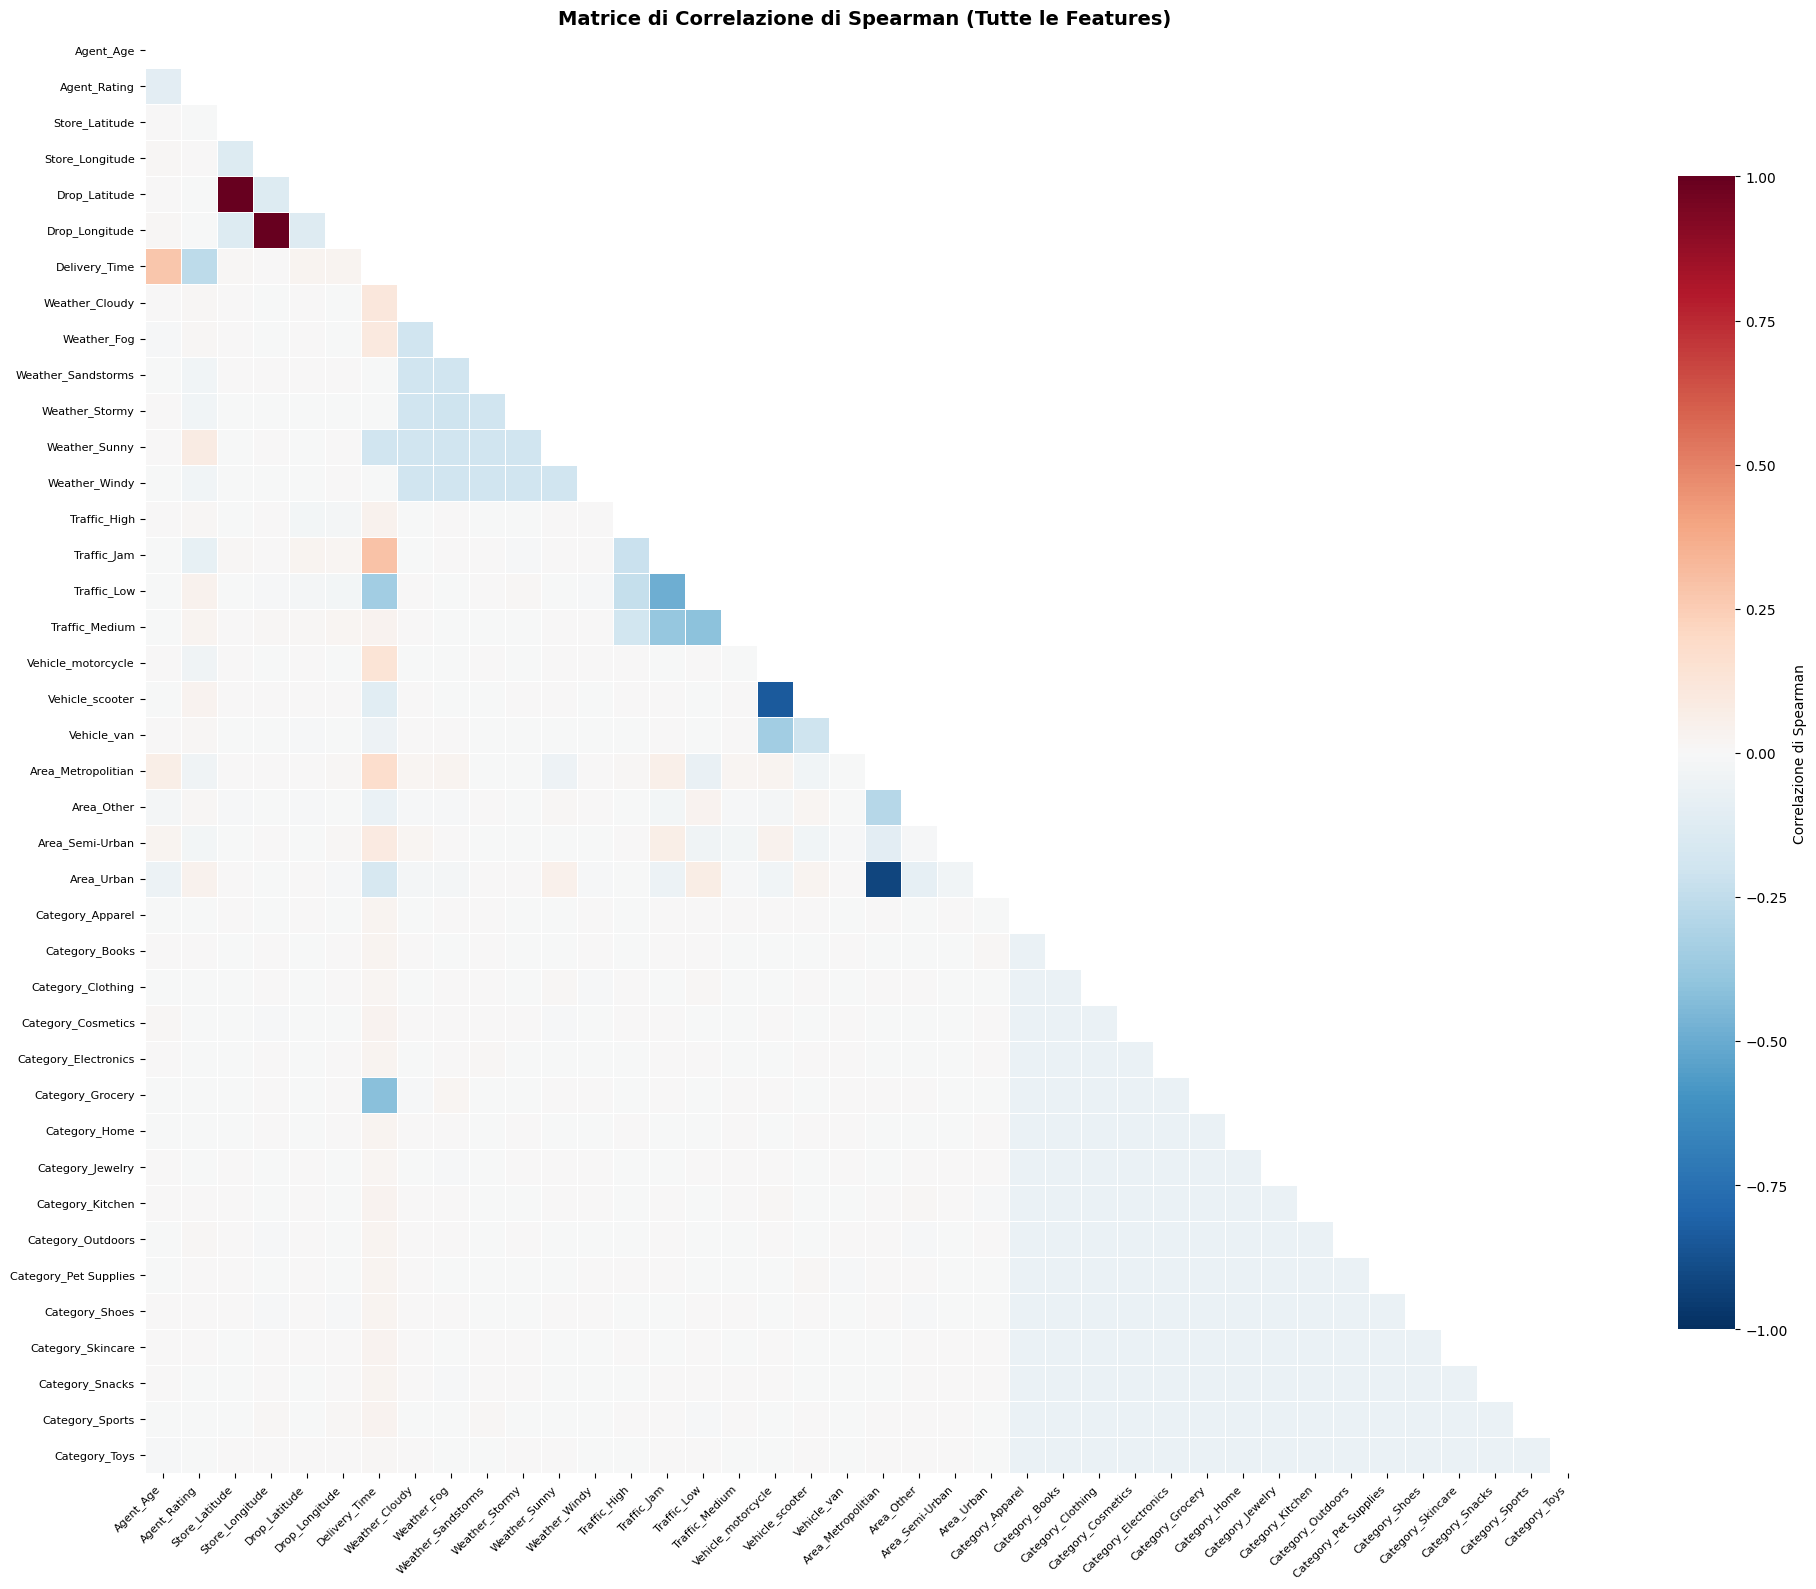


CORRELAZIONI DI SPEARMAN CON DELIVERY_TIME

📈 Top 10 correlazioni POSITIVE:
   Traffic_Jam: 0.2929
   Agent_Age: 0.2763
   Area_Metropolitian: 0.1749
   Vehicle_motorcycle: 0.1336
   Weather_Cloudy: 0.1111
   Weather_Fog: 0.0997
   Area_Semi-Urban: 0.0899
   Traffic_High: 0.0418
   Traffic_Medium: 0.0385
   Category_Sports: 0.0358

📉 Top 10 correlazioni NEGATIVE:
   Weather_Stormy: -0.0061
   Weather_Sandstorms: -0.0073
   Vehicle_van: -0.0479
   Area_Other: -0.0681
   Vehicle_scooter: -0.1120
   Area_Urban: -0.1692
   Weather_Sunny: -0.1998
   Agent_Rating: -0.2627
   Traffic_Low: -0.3479
   Category_Grocery: -0.4150


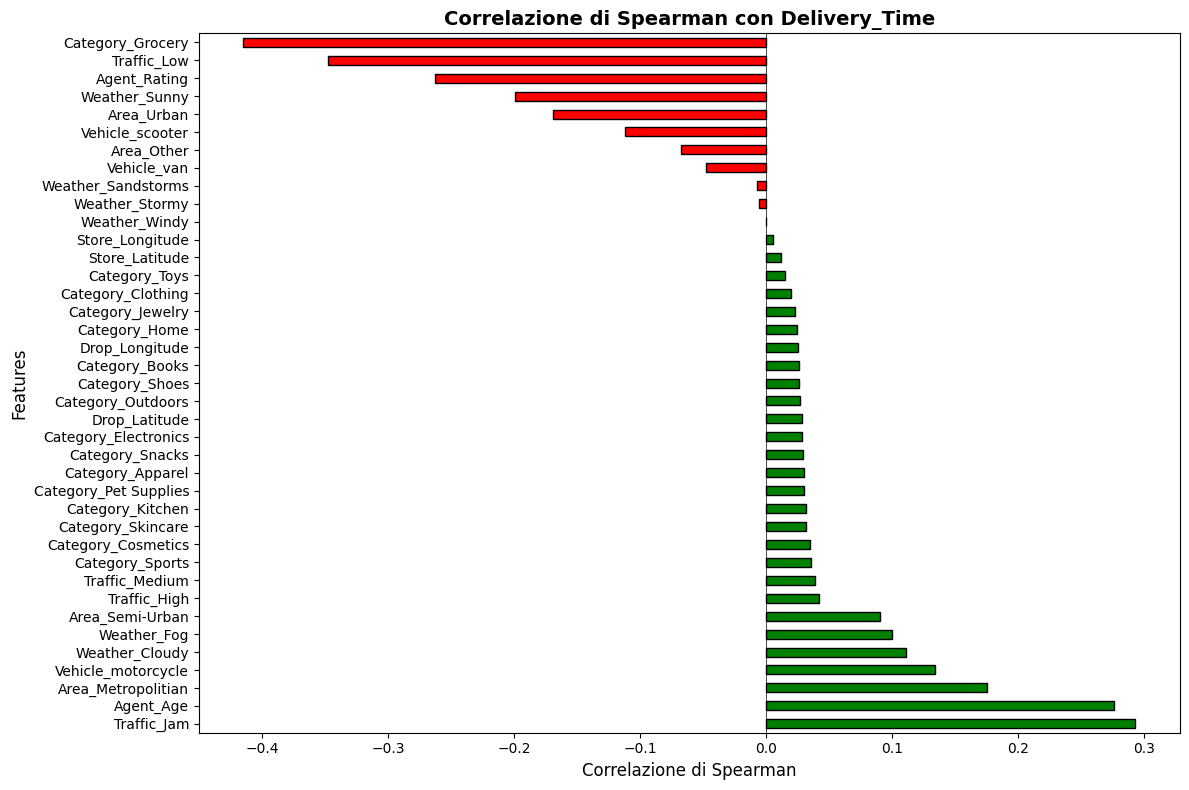


CORRELAZIONI FORTI TRA FEATURES (|corr| > 0.5)

🔗 Trovate 4 coppie con correlazione forte:
   Store_Latitude <-> Drop_Latitude: 0.9973
   Store_Longitude <-> Drop_Longitude: 0.9960
   Vehicle_motorcycle <-> Vehicle_scooter: -0.8434
   Area_Metropolitian <-> Area_Urban: -0.9211


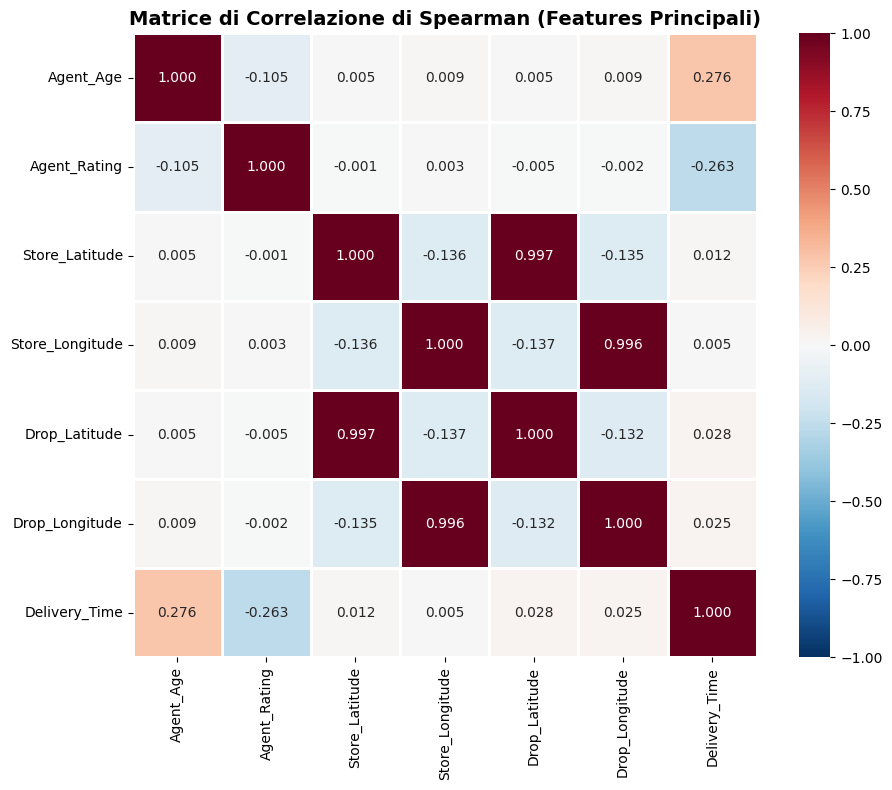


💾 Grafici salvati:
   - spearman_correlation_full.png
   - spearman_correlation_target.png
   - spearman_correlation_main.png


In [5]:
# Cella: Spearman Correlation Matrix

# Caricamento dataset finale
df = pd.read_csv('amazon_delivery_final.csv')

# Seleziona solo le colonne numeriche (escludi Order_ID)
numeric_df = df.select_dtypes(include=[np.number])

print(f"📊 Numero di features numeriche: {numeric_df.shape[1]}")

# Calcola la matrice di correlazione di Spearman
spearman_corr = numeric_df.corr(method='spearman')

# ============================================================
# HEATMAP COMPLETA
# ============================================================
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))  # Maschera triangolo superiore

sns.heatmap(spearman_corr, 
            mask=mask,
            annot=False,  # Troppi valori per annotazioni
            cmap='RdBu_r', 
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlazione di Spearman'})

plt.title('Matrice di Correlazione di Spearman (Tutte le Features)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('spearman_correlation_full.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# CORRELAZIONI CON DELIVERY_TIME (TARGET)
# ============================================================
print("\n" + "="*60)
print("CORRELAZIONI DI SPEARMAN CON DELIVERY_TIME")
print("="*60)

target_corr = spearman_corr['Delivery_Time'].drop('Delivery_Time').sort_values(ascending=False)

print("\n📈 Top 10 correlazioni POSITIVE:")
for feat, corr in target_corr.head(10).items():
    print(f"   {feat}: {corr:.4f}")

print("\n📉 Top 10 correlazioni NEGATIVE:")
for feat, corr in target_corr.tail(10).items():
    print(f"   {feat}: {corr:.4f}")

# Grafico a barre delle correlazioni con Delivery_Time
plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors, edgecolor='black')
plt.xlabel('Correlazione di Spearman', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Correlazione di Spearman con Delivery_Time', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('spearman_correlation_target.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# CORRELAZIONI FORTI TRA FEATURES (|corr| > 0.5)
# ============================================================
print("\n" + "="*60)
print("CORRELAZIONI FORTI TRA FEATURES (|corr| > 0.5)")
print("="*60)

# Trova correlazioni forti (esclusa diagonale)
strong_corr = []
for i in range(len(spearman_corr.columns)):
    for j in range(i+1, len(spearman_corr.columns)):
        corr_value = spearman_corr.iloc[i, j]
        if abs(corr_value) > 0.5:
            strong_corr.append({
                'Feature_1': spearman_corr.columns[i],
                'Feature_2': spearman_corr.columns[j],
                'Correlazione': corr_value
            })

if strong_corr:
    strong_df = pd.DataFrame(strong_corr).sort_values('Correlazione', ascending=False)
    print(f"\n🔗 Trovate {len(strong_df)} coppie con correlazione forte:")
    for _, row in strong_df.iterrows():
        print(f"   {row['Feature_1']} <-> {row['Feature_2']}: {row['Correlazione']:.4f}")
else:
    print("\n✅ Nessuna correlazione forte (|corr| > 0.5) trovata tra le features")

# ============================================================
# HEATMAP FEATURES PRINCIPALI (non OHE)
# ============================================================
main_features = ['Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 
                 'Drop_Latitude', 'Drop_Longitude', 'Delivery_Time']

main_corr = numeric_df[main_features].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(main_corr, 
            annot=True, 
            fmt='.3f',
            cmap='RdBu_r', 
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            linewidths=1,
            annot_kws={'size': 10})

plt.title('Matrice di Correlazione di Spearman (Features Principali)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('spearman_correlation_main.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Grafici salvati:")
print("   - spearman_correlation_full.png")
print("   - spearman_correlation_target.png")
print("   - spearman_correlation_main.png")